In [ ]:
pip install torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Data loading and Preprocessing
transform = transforms.Compose([  transforms.ToTensor(),])

train_dataset = torchvision.datasets.CIFAR10( root ='./data', train = True , download = True , transform = transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size = 64, shuffle = True)

test_dataset = torchvision.datasets.CIFAR10( root='./data', train=False, download = True , transform = transform)

test_loader = torch.utils.data.DataLoader( dataset=test_dataset, batch_size=6, shuffle = False)

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


In [ ]:
class SparseAutoencoder(nn.Module):
   def __init__(self):
    super(SparseAutoencoder, self).__init__()
    self.encoder = nn.Sequential(nn.Linear(3072, 1024), nn.ReLU(True), nn.Linear(1024,256), nn.ReLU(True))
    self.decoder = nn.Sequential(nn.Linear(256, 1024), nn.ReLU(True), nn.Linear(1024,3072),nn.Sigmoid())

   def forward(self, x):
      encoded =self.encoder(x)
      decoded = self.decoder(encoded)
      return  encoded, decoded


In [ ]:
def train_autoencoder(sparsity_param_val, epochs=10):
    print(f"\n--- Training with sparsity_param: {sparsity_param_val} ---")
    model = SparseAutoencoder().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        running_loss = 0.0
        for data in train_loader:
            img, _ = data
            img = img.view(img.size(0), -1)
            img = img.to(device)

            optimizer.zero_grad()
            encoded, decoded = model(img)
            mse_loss = criterion(decoded, img)
            l1_sparsity_loss = torch.mean(torch.abs(encoded))
            loss = mse_loss + (sparsity_param_val * l1_sparsity_loss)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    return model

# Experiment with different sparsity parameters
sparsity_params = [1e-4, 1e-3, 1e-2] # Example values
models_by_sparsity = {}

for sp_val in sparsity_params:
    trained_model = train_autoencoder(sp_val)
    models_by_sparsity[sp_val] = trained_model

print("\nTraining complete for all sparsity parameters.")
print("You can now access trained models using models_by_sparsity dictionary, e.g., models_by_sparsity[1e-3]")


--- Training with sparsity_param: 0.0001 ---
Epoch [1/10], Loss: 0.0233
Epoch [2/10], Loss: 0.0140
Epoch [3/10], Loss: 0.0122
Epoch [4/10], Loss: 0.0114
Epoch [5/10], Loss: 0.0111
Epoch [6/10], Loss: 0.0109
Epoch [7/10], Loss: 0.0108
Epoch [8/10], Loss: 0.0107
Epoch [9/10], Loss: 0.0106
Epoch [10/10], Loss: 0.0105

--- Training with sparsity_param: 0.001 ---
Epoch [1/10], Loss: 0.0229
Epoch [2/10], Loss: 0.0145
Epoch [3/10], Loss: 0.0129
Epoch [4/10], Loss: 0.0124
Epoch [5/10], Loss: 0.0121
Epoch [6/10], Loss: 0.0120
Epoch [7/10], Loss: 0.0119
Epoch [8/10], Loss: 0.0118
Epoch [9/10], Loss: 0.0116
Epoch [10/10], Loss: 0.0114

--- Training with sparsity_param: 0.01 ---
Epoch [1/10], Loss: 0.0383
Epoch [2/10], Loss: 0.0330
Epoch [3/10], Loss: 0.0328
Epoch [4/10], Loss: 0.0326
Epoch [5/10], Loss: 0.0307
Epoch [6/10], Loss: 0.0301
Epoch [7/10], Loss: 0.0275
Epoch [8/10], Loss: 0.0263
Epoch [9/10], Loss: 0.0261
Epoch [10/10], Loss: 0.0252

Training complete for all sparsity parameters.
You 

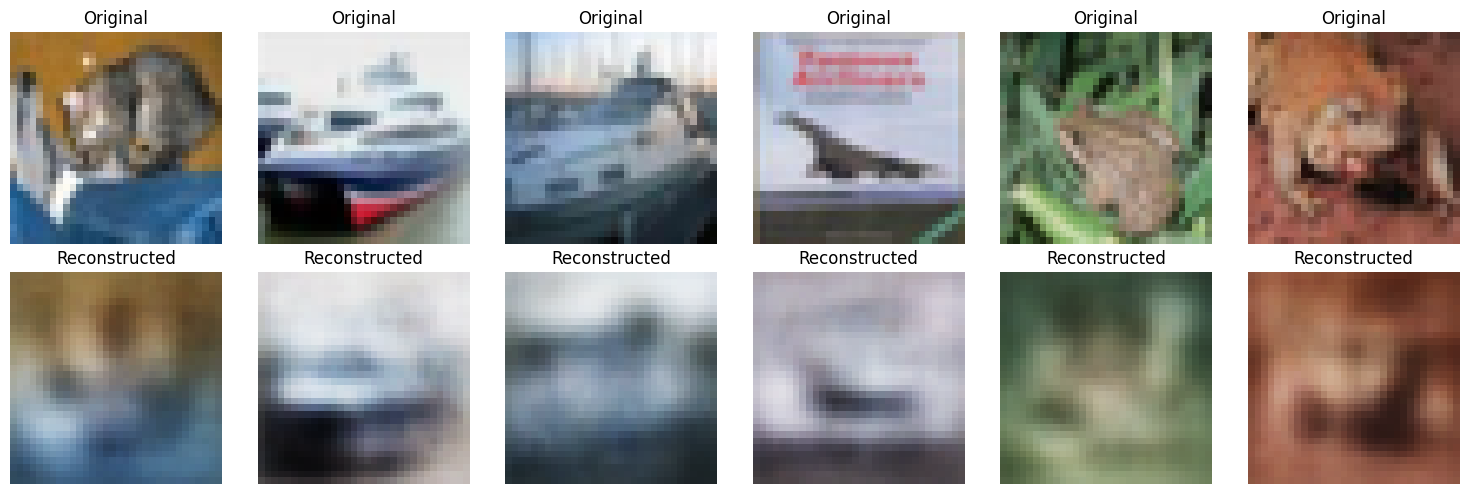

In [ ]:
with torch.no_grad():
  # Select one of the trained models from models_by_sparsity
  # For example, using the model trained with sparsity_param = 1e-4
  model = models_by_sparsity[1e-4]
  model.eval() # Set the model to evaluation mode

  detaiter = iter(test_loader)
  images,labels= next(detaiter)

  flat_images = images.view(images.size(0), -1).to(device)

  _, reconstructed = model(flat_images) #flattening the test images and passed into the model
  reconstructed = reconstructed.view(-1, 3, 32, 32).cpu() #reshaping back into 3D image tensors
  fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(15, 5)) #plotting original v/s reconstructed

for i in range(6):
#conversion of tensor into Numpy array
  #plotting original image
  orig_img = images[i].permute(1, 2, 0).numpy()
  axes[0, i].imshow(orig_img)
  axes[0, i].set_title("Original")
  axes[0, i].axis('off')
 #plotting reconstructed image
  recon_img = reconstructed[i].permute(1, 2, 0).numpy()
  axes[1, i].imshow(recon_img)
  axes[1, i].set_title("Reconstructed")
  axes[1, i].axis('off')

plt.tight_layout()
plt.show()

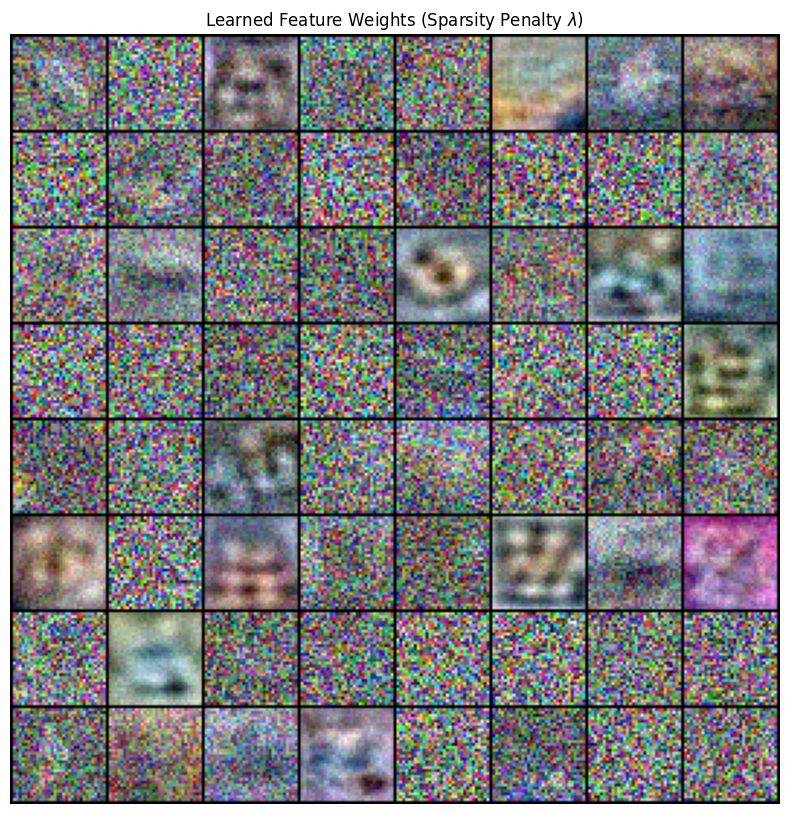

In [ ]:
weights = model.encoder[0].weight.data.clone()
weights = weights[:64]
weights = weights.view(64, 3, 32, 32)

for i in range(weights.shape[0]):
    w_min = weights[i].min()
    w_max = weights[i].max()
    # Applying min-max normalization to each filter individually
    weights[i] = (weights[i] - w_min) / (w_max - w_min + 1e-8)

grid = torchvision.utils.make_grid(weights, nrow=8, padding=1, normalize=False)

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.title(fr"Learned Feature Weights (Sparsity Penalty $\lambda$)")
plt.axis('off')
plt.show()

In [ ]:
criterion = nn.MSELoss()

model.eval() # Set the model to evaluation mode
test_reconstruction_loss = 0.0

with torch.no_grad(): # Disable gradient calculation for evaluation
    for data in test_loader:
        img, _ = data
        img = img.view(img.size(0), -1).to(device)

        _, decoded = model(img)

        # Calculate Reconstruction Loss
        mse_loss = criterion(decoded, img)
        test_reconstruction_loss += mse_loss.item()

print(f"Average Test Reconstruction Loss: {test_reconstruction_loss / len(test_loader):.4f}")

Average Test Reconstruction Loss: 0.0108



--- Reconstructions for sparsity_param = 0.0001 ---


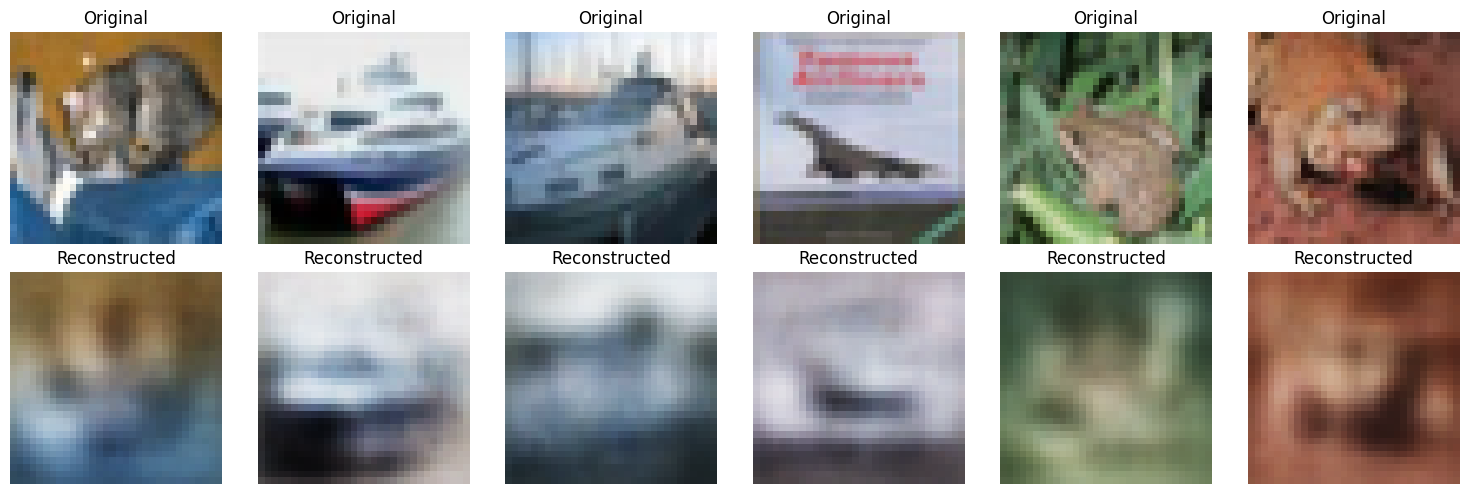


--- Reconstructions for sparsity_param = 0.001 ---


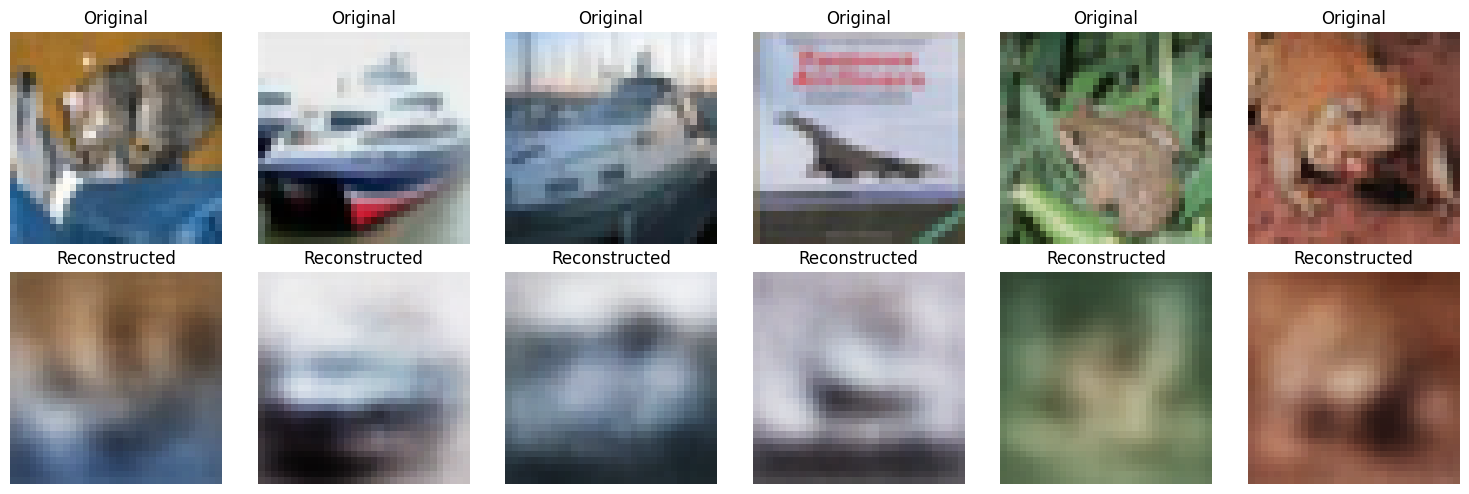


--- Reconstructions for sparsity_param = 0.01 ---


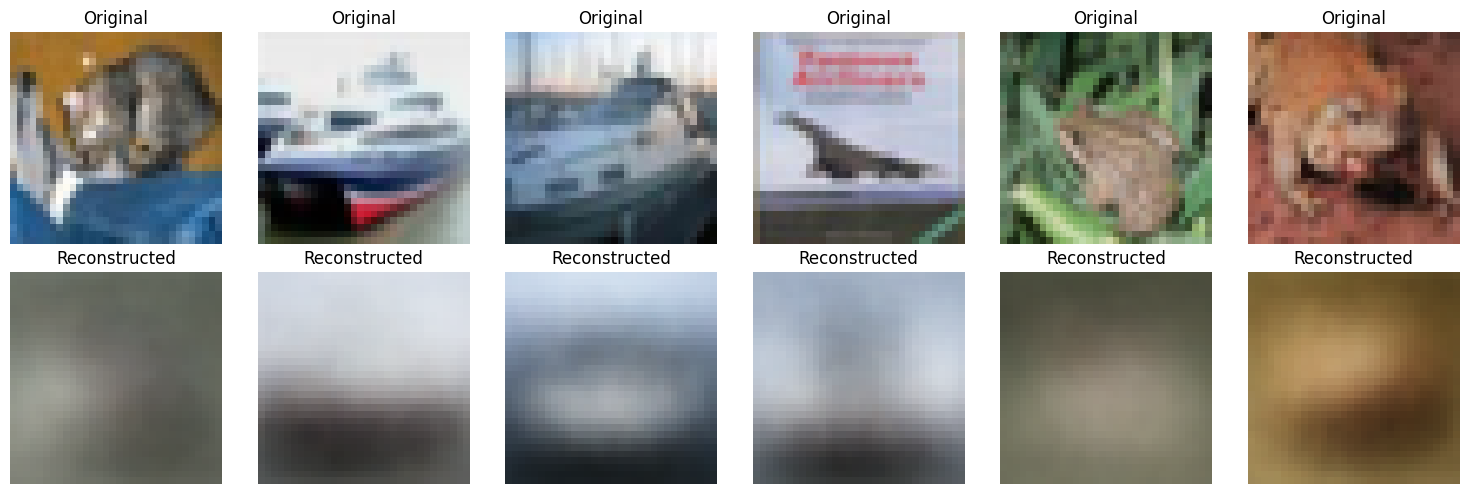

In [ ]:
# Get a batch of test images for visualization -once
with torch.no_grad():
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    # Select the first 6 images for consistent comparison across models
    sample_images = images[:6]
    flat_sample_images = sample_images.view(sample_images.size(0), -1).to(device)

# Visualize reconstructions for each sparsity parameter
# Check if models_by_sparsity is defined. If not, the user is informed to run the training cell.
if 'models_by_sparsity' not in locals() and 'models_by_sparsity' not in globals():
    print("Error: 'models_by_sparsity' is not defined. Please ensure the training cell (bUrcnOiqTX6N) has been run successfully to train the models.")
else:
    for sp_val, model in models_by_sparsity.items():
        model.eval()
        with torch.no_grad():
            _, reconstructed = model(flat_sample_images)
            reconstructed = reconstructed.view(-1, 3, 32, 32).cpu()

        print(f"\n--- Reconstructions for sparsity_param = {sp_val} ---")
        fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(15, 5))

        for i in range(6):
            # Plot original image
            orig_img = sample_images[i].permute(1, 2, 0).numpy()
            axes[0, i].imshow(orig_img)
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')

            # Plot reconstructed image
            recon_img = reconstructed[i].permute(1, 2, 0).numpy()
            axes[1, i].imshow(recon_img)
            axes[1, i].set_title("Reconstructed")
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()


--- Learned Feature Weights for sparsity_param = 0.0001 ---


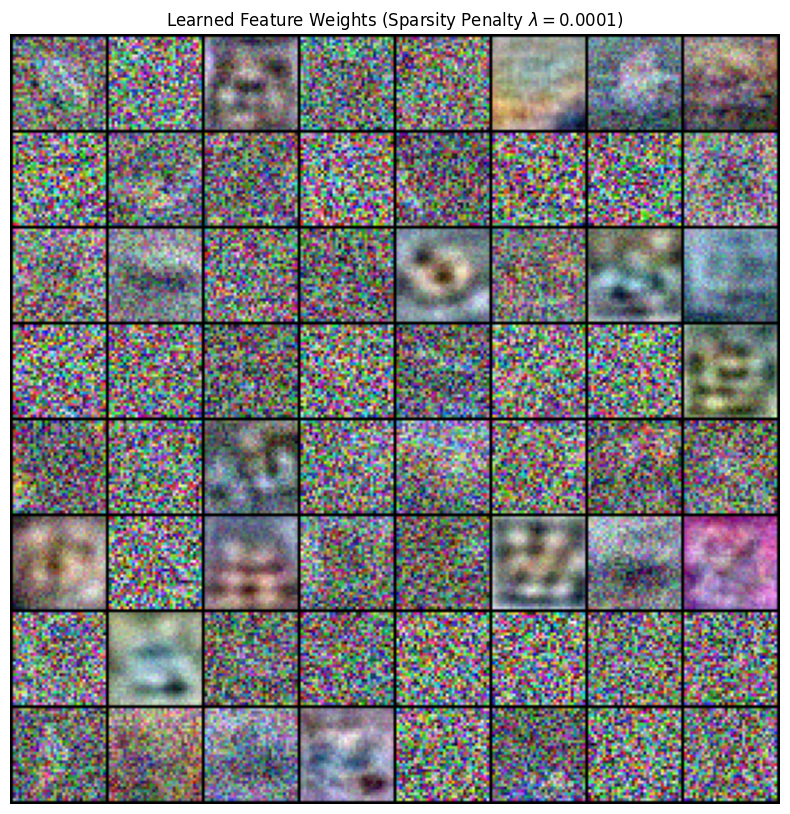


--- Learned Feature Weights for sparsity_param = 0.001 ---


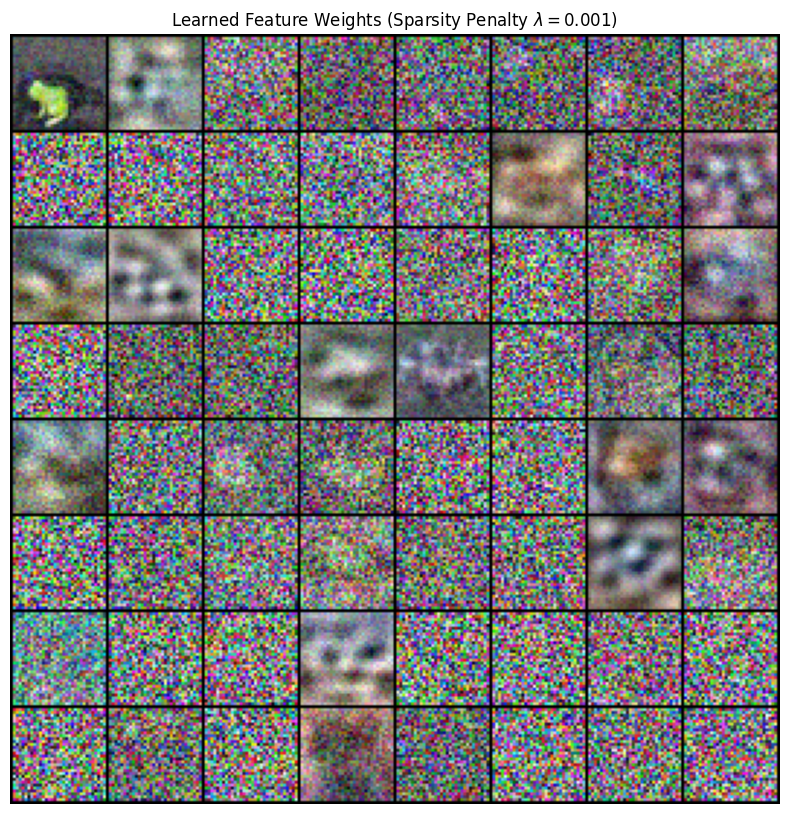


--- Learned Feature Weights for sparsity_param = 0.01 ---


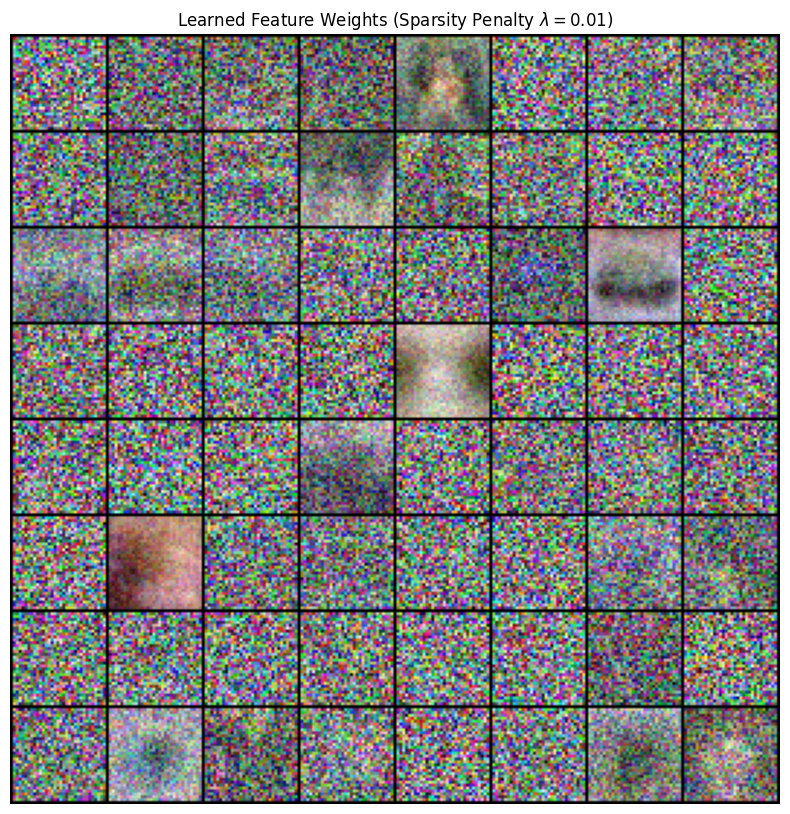

In [ ]:
# Visualize learned feature weights for each sparsity parameter
for sp_val, model in models_by_sparsity.items():
    print(f"\n--- Learned Feature Weights for sparsity_param = {sp_val} ---")
    model.eval()
    weights = model.encoder[0].weight.data.clone()
    weights = weights[:64] # Display first 64 filters
    weights = weights.view(64, 3, 32, 32)

    for i in range(weights.shape[0]):
        w_min = weights[i].min()
        w_max = weights[i].max()
        # Applying min-max normalization to each filter individually
        weights[i] = (weights[i] - w_min) / (w_max - w_min + 1e-8)

    grid = torchvision.utils.make_grid(weights, nrow=8, padding=1, normalize=False)

    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(fr"Learned Feature Weights (Sparsity Penalty $\lambda = {sp_val}$)")
    plt.axis('off')
    plt.show()

The code thoroughly addresses the implementation, training, and evaluation of a Sparse Autoencoder on the CIFAR-10 dataset, emphasizing the impact of sparsity regularization. It begins by setting up the PyTorch environment, installing necessary libraries like torchvision, and configuring the computation device (GPU if available). The data loading and preprocessing steps involve fetching the CIFAR-10 dataset, applying transformations like ToTensor() to normalize pixel values, and preparing data loaders for batch processing. The core of the implementation is the SparseAutoencoder class, which defines the network's architecture with an encoder that compresses 3072-dimensional image vectors (from flattened 32x32x3 CIFAR-10 images) into a 256-dimensional latent space, and a decoder that reconstructs the images back to 3072 dimensions, using nn.Linear layers and ReLU activations, with a final Sigmoid for output scaling. The training process, encapsulated in train_autoencoder, utilizes nn.MSELoss for reconstruction and importantly incorporates an L1 sparsity penalty (torch.mean(torch.abs(encoded))) on the latent representation to encourage sparse activations. The total loss combines MSE and the weighted sparsity penalty, which is then optimized using Adam. A significant part of the experiment involves training multiple models with varying sparsity_param_val (e.g., 1e-4, 1e-3, 1e-2) to observe its effects. Finally, the evaluation and visualization phases offer insights into the model's performance:

Reconstruction Visualization: Comparing original CIFAR-10 images with their autoencoder-reconstructed versions for selected models and across different sparsity parameters.
Learned Feature Weights: Visualizing the weights of the first encoder layer as 'features' or 'filters', providing insight into what patterns the autoencoder has learned from the data.
Quantitative Evaluation: Calculating the average Mean Squared Error (MSE) reconstruction loss on the test dataset to assess the model's performance numerically.